bold text#  Lead Conversion Prediction — End-to-End ML Pipeline

**DigiHust Assignment A02**

---

## Business Problem

X Education sells online courses. The company generates a large number of
**leads** — potential customers who show interest by visiting the website,
filling forms, or chatting with representatives.

However, only a fraction of these leads actually purchase a course (i.e. **convert**).
The company wants to identify which leads are **most likely to convert** so the
sales team can focus their efforts on high-potential leads.

## ML Objective

Build a **binary classification model** that predicts whether a lead will
convert (`1`) or not (`0`) based on available lead information.

## Target Variable

- **`Converted`** — `1` = lead purchased the course, `0` = did not.

## Why This Matters

- **For the business:** Focus sales effort on leads with high predicted
  conversion probability → better conversion rates, lower cost per acquisition.
- **For us (learning):** Walk through every stage of a real ML pipeline —
  from raw data to an evaluated, interpretable model.

## Success Metrics

We will use **F1-Score** and **ROC-AUC** as primary metrics rather than
plain accuracy, because:
1. The classes are **moderately imbalanced** (~62 % / 38 %).
2. Both false positives (wasting sales effort) and false negatives
   (missing actual converters) have real business cost.

---
# 2. Import Libraries

We import everything up front so that missing packages surface early.

| Library | Purpose |
|---------|---------|
| **pandas** | Data manipulation (DataFrames) |
| **numpy** | Numerical operations |
| **matplotlib / seaborn** | Visualisation |
| **scikit-learn** | ML models, pipelines, metrics |

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
# Standard libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" All libraries imported successfully.")

 All libraries imported successfully.


---
# 3. Load Dataset

**Google Colab users:** When the cell below runs, it will try to detect
whether you are in Colab. If so, you will be prompted to upload `Leads.csv`.

**Local users:** The cell falls back to `../data/raw/Leads.csv`.

In [84]:
import os

# Detect environment and load
try:
    from google.colab import files
    print("Running in Google Colab — please upload Leads.csv:")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
except (ImportError, ModuleNotFoundError):
    DATA_PATH = "/content/drive/My Drive/Datasets/Leads_Dataset/Leads.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"\nDataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Running in Google Colab — please upload Leads.csv:


Saving Leads.csv to Leads (2).csv

Dataset loaded: 9,240 rows × 37 columns


### First look at the data

`df.head()` shows the first five rows. Reading a few rows gives us an
intuitive feel for the kind of information each column contains.

In [85]:
df_raw.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [86]:
df_raw.tail()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,...,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,...,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,...,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


---
# 4. Initial Data Understanding

Before building any model we need to answer:
1. How many rows and columns do we have?
2. What are the data types?
3. How much data is missing?
4. What does the target variable look like?

### 4.1 Shape & Data Types

In [87]:
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nMemory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: 9,240 rows × 37 columns

Memory usage: 15.4 MB


In [88]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

### 4.2 Statistical Summary

`describe()` gives count, mean, std, min, percentiles, and max for every
numeric column. Look for:
- **Large gaps between mean and median (50 %)** → potential outliers or skew.
- **Min/max values that seem unreasonable** → data-entry errors.

In [89]:
df_raw.describe().round(2)

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.00,9240.00,9103.00,9240.00,9103.00,5022.00,5022.00
mean,617188.44,0.39,3.45,487.70,2.36,14.31,16.34
std,23406.00,0.49,4.85,548.02,2.16,1.39,1.81
min,579533.00,0.00,0.00,0.00,0.00,7.00,11.00
25%,596484.50,0.00,1.00,12.00,1.00,14.00,15.00
50%,615479.00,0.00,3.00,248.00,2.00,14.00,16.00
75%,637387.25,1.00,5.00,936.00,3.00,15.00,18.00
max,660737.00,1.00,251.00,2272.00,55.00,18.00,20.00


### 4.3 Data Dictionary

The table below explains every column in the dataset. This was built by
inspecting column names, unique values, and the provided data dictionary.

| # | Column | Type | Description |
|---|--------|------|-------------|
| 0 | Prospect ID | ID | Unique identifier for each lead |
| 1 | Lead Number | ID | Sequential lead number |
| 2 | Lead Origin | Categorical | Channel through which the lead was created (API, Landing Page, etc.) |
| 3 | Lead Source | Categorical | Source of the lead (Google, Direct Traffic, Olark Chat, etc.) |
| 4 | Do Not Email | Binary | Whether the lead opted out of emails |
| 5 | Do Not Call | Binary | Whether the lead opted out of calls |
| 6 | **Converted** | **Target** | **1 = converted (purchased), 0 = did not** |
| 7 | TotalVisits | Numerical | Total website visits |
| 8 | Total Time Spent on Website | Numerical | Total seconds spent on the website |
| 9 | Page Views Per Visit | Numerical | Average page views per visit |
| 10 | Last Activity | Categorical | Last recorded activity (Email Opened, SMS Sent, etc.) |
| 11 | Country | Categorical | Lead's country |
| 12 | Specialization | Categorical | Specialization of interest |
| 13 | How did you hear about X Education | Categorical | Awareness channel |
| 14 | What is your current occupation | Categorical | Employment status |
| 15 | What matters most to you in choosing a course | Categorical | Decision factor |
| 16–22 | Search, Magazine, Newspaper, etc. | Binary (Yes/No) | Marketing channel activity flags |
| 23 | Receive More Updates About Our Courses | Binary | Opted-in for updates |
| 24 | Tags | Categorical | CRM tags assigned to the lead |
| 25 | Lead Quality | Categorical | Internal quality assessment |
| 26–27 | Update me on Supply Chain / DM Content | Binary | Content preference flags |
| 28 | Lead Profile | Categorical | Internal lead profile category |
| 29 | City | Categorical | Lead's city |
| 30–33 | Asymmetrique Activity/Profile Index/Score | Mixed | Third-party lead scoring |
| 34 | I agree to pay the amount through cheque | Binary | Payment-mode preference |
| 35 | A free copy of Mastering The Interview | Binary | Opted-in for free book |
| 36 | Last Notable Activity | Categorical | Last significant CRM activity |

### 4.4 Target Variable Distribution

The **most important** first question: how is the target distributed?

If classes are heavily imbalanced (e.g., 95 % / 5 %), a model that always
predicts the majority class would get 95 % accuracy but be useless.
We need to know this before choosing metrics and training strategies.

In [90]:
target_counts = df_raw["Converted"].value_counts()
target_pct = df_raw["Converted"].value_counts(normalize=True) * 100

print("Target distribution:")
print(f"  0 (Not Converted): {target_counts[0]:,}  ({target_pct[0]:.1f}%)")
print(f"  1 (Converted):     {target_counts[1]:,}  ({target_pct[1]:.1f}%)")
print(f"\nImbalance ratio: {target_counts[0] / target_counts[1]:.2f} : 1")

Target distribution:
  0 (Not Converted): 5,679  (61.5%)
  1 (Converted):     3,561  (38.5%)

Imbalance ratio: 1.59 : 1


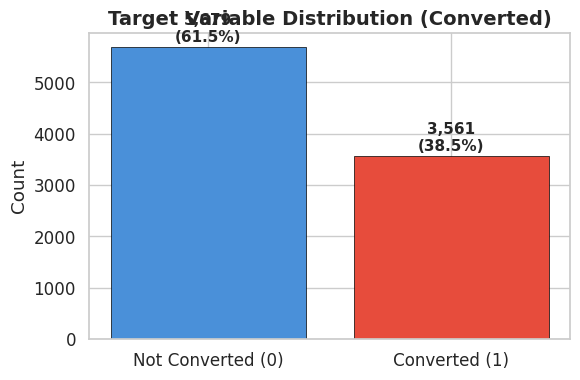

In [91]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4A90D9", "#E74C3C"]
bars = ax.bar(["Not Converted (0)", "Converted (1)"],
              target_counts.values, color=colors, edgecolor="black", linewidth=0.5)

for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Count")
ax.set_title("Target Variable Distribution (Converted)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:**

The dataset has a **moderate class imbalance** (~62 % not converted vs. ~38 % converted).
This is not extreme, but it means:
- **Accuracy alone is misleading** — a dummy model predicting "Not Converted" for
  everyone would score ~62 % accuracy.
- We should use **F1-Score** (balances precision and recall) and **ROC-AUC**
  (measures discrimination ability across all thresholds) as our primary metrics.
- We may want to use `class_weight='balanced'` in our models to give more
  importance to the minority class during training.

---
# 5. Data Quality Assessment

Clean data is the foundation of any ML project. We will check for:

1. **Missing values** — can distort model training
2. **"Select" placeholder values** — hidden missing values
3. **Constant columns** — columns with only one unique value (zero information)
4. **Duplicate records** — can bias the model

---

## 5.1 Missing Values

### Why missing values matter
- Most ML algorithms **cannot handle NaN** directly.
- If we ignore missing values, we lose rows and potentially introduce bias.
- The **pattern** of missingness matters: is it random, or related to the target?

In [92]:
# Count missing values and calculate percentages
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing %", ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df["Missing Count"] > 0]
print(f"Columns with missing values: {len(missing_df)} out of {df_raw.shape[1]}")
print()
missing_df

Columns with missing values: 17 out of 37



,Missing Count,Missing %
Lead Quality,4767,51.59
Asymmetrique Profile Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Profile Score,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


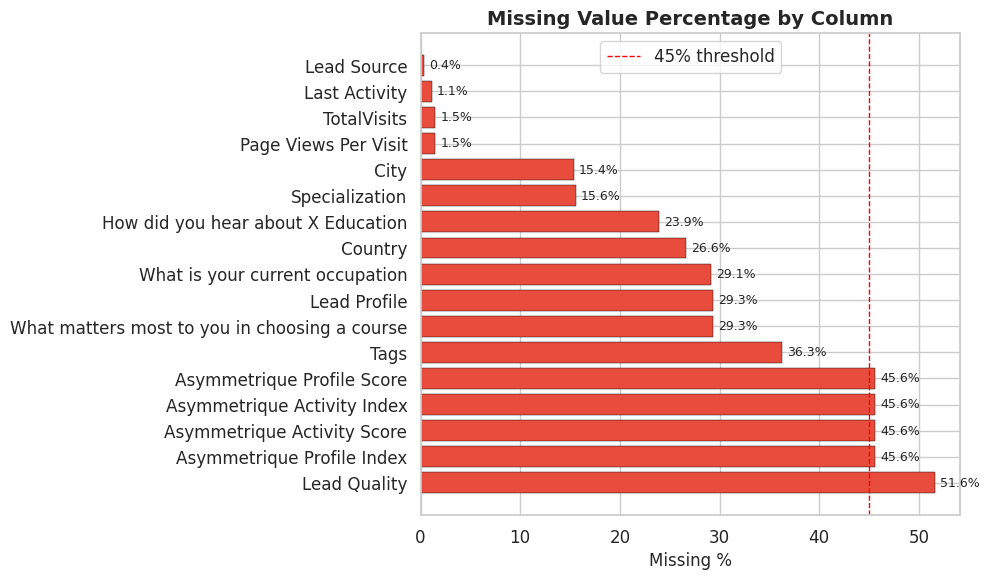

In [93]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
cols_with_missing = missing_df.index.tolist()
bars = ax.barh(cols_with_missing, missing_df["Missing %"], color="#E74C3C", edgecolor="black", linewidth=0.3)
ax.set_xlabel("Missing %", fontsize=12)
ax.set_title("Missing Value Percentage by Column", fontsize=14, fontweight="bold")
ax.axvline(x=45, color="red", linestyle="--", linewidth=1, label="45% threshold")
ax.legend()

for bar, pct in zip(bars, missing_df["Missing %"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 5.2 "Select" Placeholder Values — Hidden Missing Data

Several categorical columns contain the value `"Select"`. This is a
**dropdown default** — the lead never actively chose an answer. It is
functionally the same as a missing value.

Let's identify which columns contain "Select" and how many:

In [94]:
# Identify columns with "Select" values
select_info = {}
for col in df_raw.select_dtypes(include=["object", "string"]).columns:
    select_count = (df_raw[col] == "Select").sum()
    if select_count > 0:
        select_info[col] = select_count

print("Columns with 'Select' placeholder values:\n")
for col, count in sorted(select_info.items(), key=lambda x: -x[1]):
    pct = count / len(df_raw) * 100
    print(f"  {col}: {count:,} ({pct:.1f}%)")

Columns with 'Select' placeholder values:

  How did you hear about X Education: 5,043 (54.6%)
  Lead Profile: 4,146 (44.9%)
  City: 2,249 (24.3%)
  Specialization: 1,942 (21.0%)


**Decision:** We replace `"Select"` with `NaN` because these are not real
answers — they represent "no selection made", which is functionally missing data.

This gives us a more honest picture of the actual missing-data situation.

In [95]:
# Make a working copy and replace 'Select' with NaN
df = df_raw.copy()

select_columns = ["Specialization", "How did you hear about X Education",
                  "Lead Profile", "City"]

for col in select_columns:
    df[col] = df[col].replace("Select", np.nan)

# Verify
for col in select_columns:
    new_missing = df[col].isnull().sum()
    print(f"{col}: now {new_missing:,} missing ({new_missing / len(df) * 100:.1f}%)")

Specialization: now 3,380 missing (36.6%)
How did you hear about X Education: now 7,250 missing (78.5%)
Lead Profile: now 6,855 missing (74.2%)
City: now 3,669 missing (39.7%)


## 5.3 Duplicate Records

Duplicate rows can bias the model by giving more weight to certain
observations. Let's check:

In [96]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

if dup_count > 0:
    print(f"\nRemoving {dup_count} duplicate rows...")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Shape after removing duplicates: {df.shape}")
else:
    print("No duplicates found — data is clean in this regard.")

Duplicate rows: 0
No duplicates found — data is clean in this regard.


## 5.4 Constant (Zero-Variance) Columns

Columns where every row has the **same value** provide no information for
distinguishing converted vs. non-converted leads. They should be dropped.

In [97]:
# Identify columns with only 1 unique value
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

print(f"Constant columns ({len(constant_cols)}):\n")
for col in constant_cols:
    unique_val = df[col].unique()
    print(f"  {col}: all values = {unique_val}")

Constant columns (5):

  Magazine: all values = ['No']
  Receive More Updates About Our Courses: all values = ['No']
  Update me on Supply Chain Content: all values = ['No']
  Get updates on DM Content: all values = ['No']
  I agree to pay the amount through cheque: all values = ['No']


In [98]:
# Drop constant columns
df = df.drop(columns=constant_cols)
print(f"\nDropped {len(constant_cols)} constant columns.")
print(f"Shape: {df.shape}")


Dropped 5 constant columns.
Shape: (9240, 32)


## 5.5 ID Columns

`Prospect ID` and `Lead Number` are unique identifiers. They have no
predictive value — in fact, including them could cause the model to
memorise specific IDs, which is a form of **overfitting**.

In [99]:
id_cols = ["Prospect ID", "Lead Number"]
df = df.drop(columns=id_cols)
print(f"Dropped ID columns: {id_cols}")
print(f"Shape: {df.shape}")

Dropped ID columns: ['Prospect ID', 'Lead Number']
Shape: (9240, 30)


## 5.6 High-Missingness Columns

Columns with very high percentages of missing data (>45 %) are unreliable:
- Imputing them would be mostly guesswork.
- They may introduce noise rather than signal.

Let's also check columns with near-zero variance or overwhelming dominance
of a single value.

In [100]:
# Re-check missing values after Select → NaN treatment
missing_after = df.isnull().sum()
missing_after_pct = (missing_after / len(df) * 100).round(2)

high_missing = missing_after_pct[missing_after_pct > 45].sort_values(ascending=False)
print("Columns with > 45% missing values:\n")
print(high_missing)

Columns with > 45% missing values:

How did you hear about X Education    78.46
Lead Profile                          74.19
Lead Quality                          51.59
Asymmetrique Activity Index           45.65
Asymmetrique Profile Index            45.65
Asymmetrique Activity Score           45.65
Asymmetrique Profile Score            45.65
dtype: float64


In [101]:
# Drop high-missing columns
high_missing_cols = high_missing.index.tolist()
df = df.drop(columns=high_missing_cols)
print(f"\nDropped {len(high_missing_cols)} high-missing columns: {high_missing_cols}")
print(f"Shape: {df.shape}")


Dropped 7 high-missing columns: ['How did you hear about X Education', 'Lead Profile', 'Lead Quality', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']
Shape: (9240, 23)


## 5.7 Near-Zero-Signal Columns

Let's also check for columns where a single value overwhelmingly dominates,
making the column nearly useless for prediction:

In [102]:
# Check for near-zero variance categorical columns
print("Columns where >95% of values are the same:\n")

low_signal_cols = []
for col in df.select_dtypes(include=["object", "string"]).columns:
    top_val_pct = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
    if top_val_pct > 95:
        top_val = df[col].value_counts(dropna=False).index[0]
        print(f"  {col}: '{top_val}' appears in {top_val_pct:.1f}% of rows")
        low_signal_cols.append(col)

# Also check 'Country' — 90%+ India, 27% missing
if "Country" in df.columns:
    india_pct = (df["Country"] == "India").sum() / df["Country"].notna().sum() * 100
    country_missing = df["Country"].isnull().sum() / len(df) * 100
    print(f"\n  Country: {india_pct:.1f}% India (of non-missing), {country_missing:.1f}% missing")
    low_signal_cols.append("Country")

# 'How did you hear about X Education' — now 78% missing after Select→NaN
if "How did you hear about X Education" in df.columns:
    col = "How did you hear about X Education"
    miss = df[col].isnull().sum() / len(df) * 100
    print(f"  {col}: {miss:.1f}% missing (after Select→NaN)")
    if col not in low_signal_cols:
        low_signal_cols.append(col)

Columns where >95% of values are the same:

  Do Not Call: 'No' appears in 100.0% of rows
  Search: 'No' appears in 99.8% of rows
  Newspaper Article: 'No' appears in 100.0% of rows
  X Education Forums: 'No' appears in 100.0% of rows
  Newspaper: 'No' appears in 100.0% of rows
  Digital Advertisement: 'No' appears in 100.0% of rows
  Through Recommendations: 'No' appears in 99.9% of rows

  Country: 95.8% India (of non-missing), 26.6% missing


In [103]:
# Drop low-signal columns
existing_low_signal = [c for c in low_signal_cols if c in df.columns]
if existing_low_signal:
    df = df.drop(columns=existing_low_signal)
    print(f"✅ Dropped {len(existing_low_signal)} low-signal columns: {existing_low_signal}")
print(f"\nCleaned dataset shape: {df.shape}")
print(f"\nRemaining columns ({df.shape[1]}):")
for i, col in enumerate(df.columns):
    print(f"  {i}: {col}")

✅ Dropped 8 low-signal columns: ['Do Not Call', 'Search', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Country']

Cleaned dataset shape: (9240, 15)

Remaining columns (15):
  0: Lead Origin
  1: Lead Source
  2: Do Not Email
  3: Converted
  4: TotalVisits
  5: Total Time Spent on Website
  6: Page Views Per Visit
  7: Last Activity
  8: Specialization
  9: What is your current occupation
  10: What matters most to you in choosing a course
  11: Tags
  12: City
  13: A free copy of Mastering The Interview
  14: Last Notable Activity


## 5.8 Data Quality Summary

| Action | Columns Affected | Reason |
|--------|-----------------|--------|
| "Select" → NaN | Specialization, Lead Profile, City, How did you hear… | Placeholder, not real answers |
| Drop constant | Magazine, Receive More Updates…, Update Supply Chain…, Get DM…, Agree cheque | Only 1 unique value |
| Drop IDs | Prospect ID, Lead Number | No predictive value |
| Drop high-missing (>45%) | Asymmetrique ×4, Lead Quality | Too much data missing to impute reliably |
| Drop low-signal | Country, What matters most…, How did you hear… | >95% one value or >75% missing |
| Duplicates | None | 0 duplicates found |

The remaining missing values will be handled via **imputation** inside the
scikit-learn pipeline (Section 11).

---
# 6. Exploratory Data Analysis (EDA)

**Purpose:** Understand the relationships between features and the target
variable. This helps us:
- Identify which features are likely predictive.
- Spot data issues we might have missed.
- Build intuition before modelling.

---

## 6.1 Numerical Feature Distributions

Let's look at the distribution of our numerical features. Heavily skewed
distributions or extreme outliers may need treatment.

In [104]:
numerical_cols_eda = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols_eda = [c for c in numerical_cols_eda if c != "Converted"]

print(f"Numerical features: {numerical_cols_eda}")
print()
df[numerical_cols_eda].describe().round(2)

Numerical features: ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']



,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,9103.00,9240.00,9103.00
mean,3.45,487.70,2.36
std,4.85,548.02,2.16
min,0.00,0.00,0.00
25%,1.00,12.00,1.00
50%,3.00,248.00,2.00
75%,5.00,936.00,3.00
max,251.00,2272.00,55.00


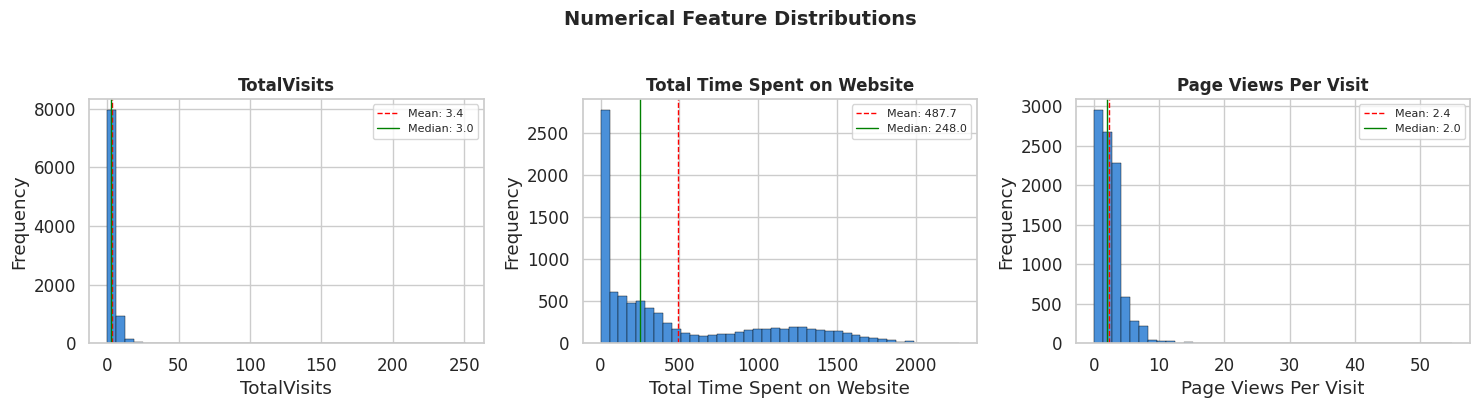

In [105]:
fig, axes = plt.subplots(1, len(numerical_cols_eda), figsize=(5 * len(numerical_cols_eda), 4))
if len(numerical_cols_eda) == 1:
    axes = [axes]

for ax, col in zip(axes, numerical_cols_eda):
    df[col].dropna().hist(bins=40, ax=ax, color="#4A90D9", edgecolor="black", linewidth=0.3)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1, label=f"Mean: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="green", linestyle="-", linewidth=1, label=f"Median: {df[col].median():.1f}")
    ax.legend(fontsize=8)

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6.2 Numerical Features vs. Target (Boxplots)

Boxplots separated by the target show whether the feature's distribution
differs between converted and non-converted leads. A clear separation
suggests the feature may be predictive.

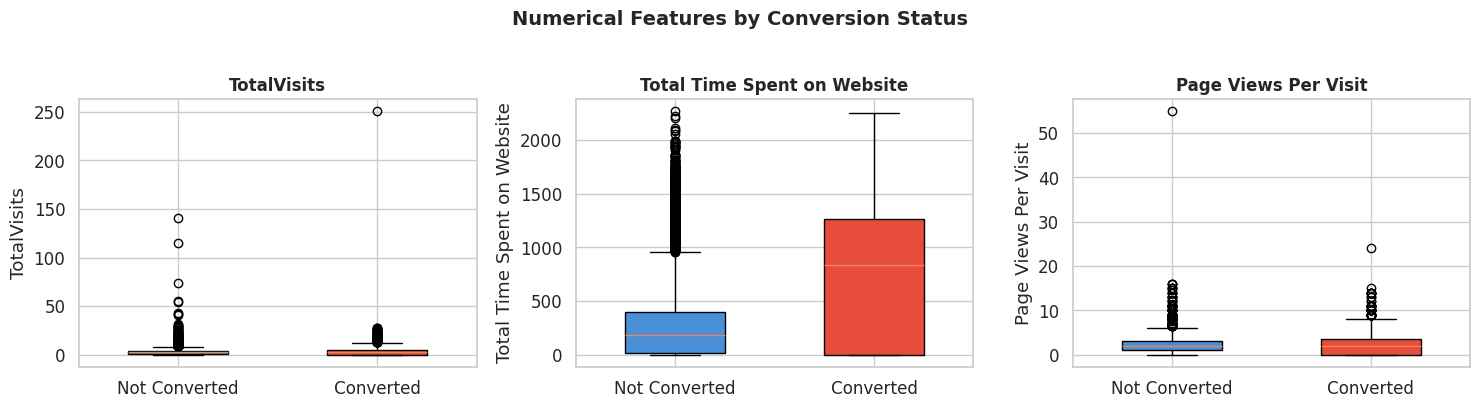

In [106]:
fig, axes = plt.subplots(1, len(numerical_cols_eda), figsize=(5 * len(numerical_cols_eda), 4))
if len(numerical_cols_eda) == 1:
    axes = [axes]

for ax, col in zip(axes, numerical_cols_eda):
    data_0 = df[df["Converted"] == 0][col].dropna()
    data_1 = df[df["Converted"] == 1][col].dropna()
    bp = ax.boxplot([data_0, data_1], labels=["Not Converted", "Converted"],
                    patch_artist=True, widths=0.5)
    bp["boxes"][0].set_facecolor("#4A90D9")
    bp["boxes"][1].set_facecolor("#E74C3C")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel(col)

plt.suptitle("Numerical Features by Conversion Status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **Total Time Spent on Website** shows a clear difference — converted leads
  tend to spend **more time** on the website. This is likely the strongest
  numerical predictor.
- **TotalVisits** and **Page Views Per Visit** have visible outliers
  (very long upper whiskers) but similar medians across groups.

## 6.3 Categorical Features vs. Conversion Rate

For categorical features, we look at the **conversion rate** within each
category. Categories with very different conversion rates are likely
informative.

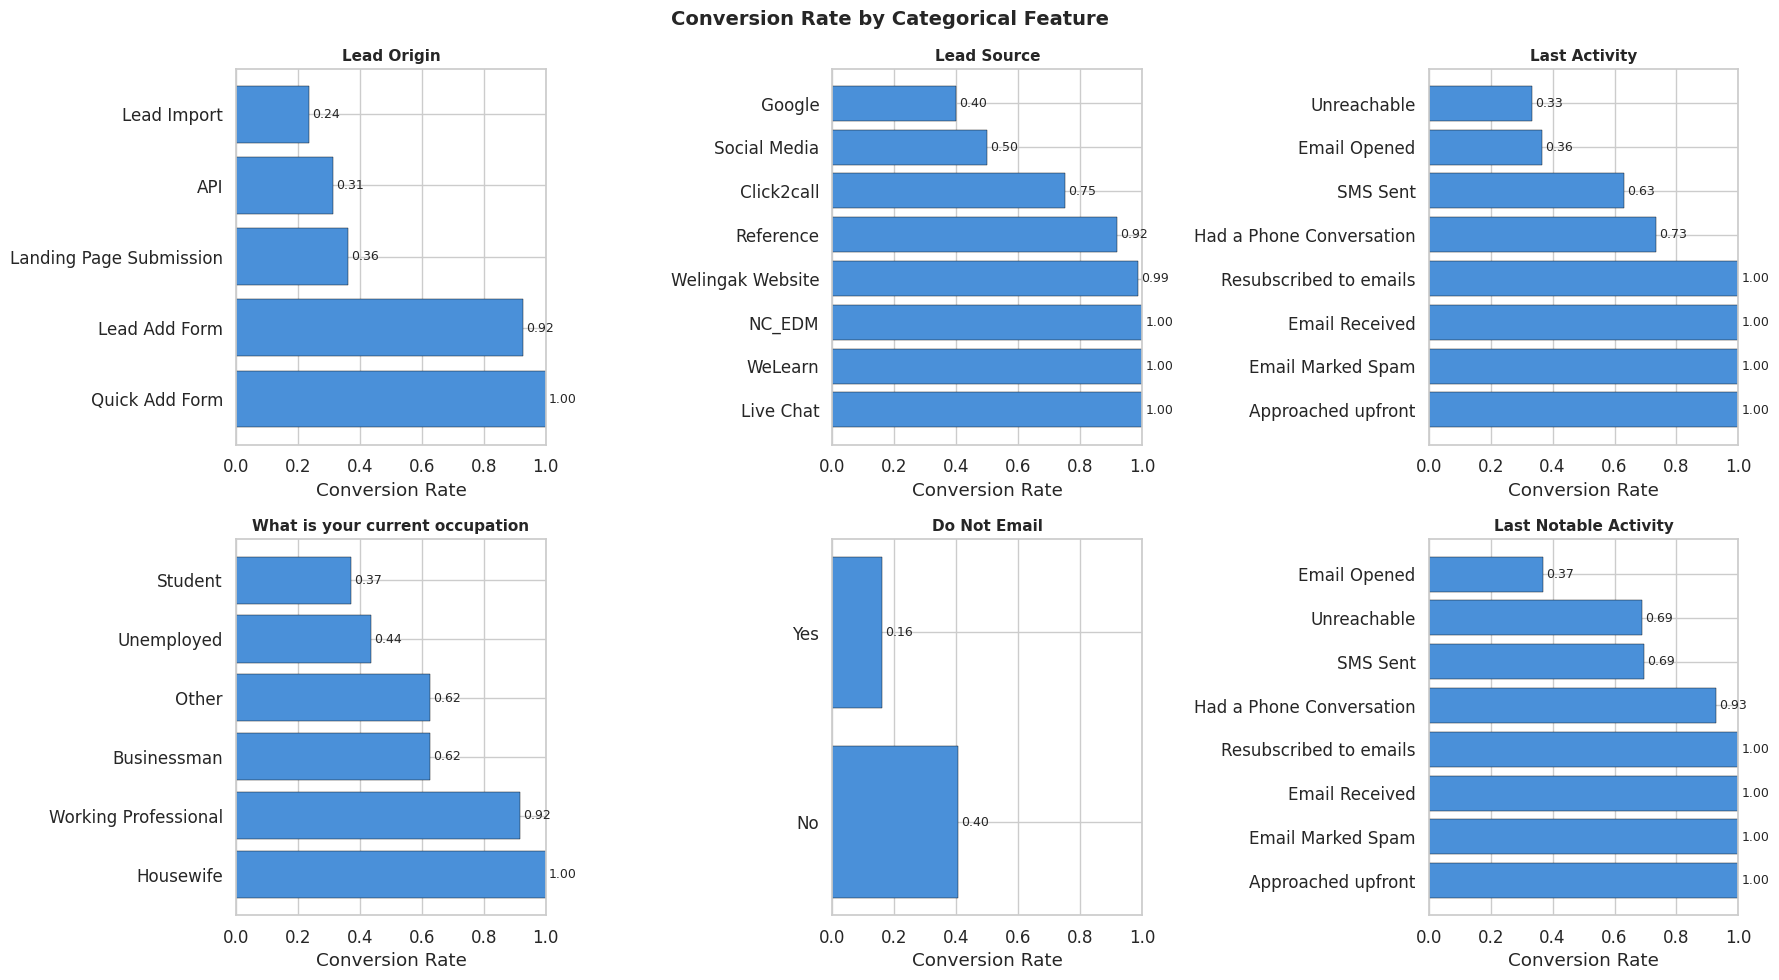

In [107]:
# Select the most interesting categorical columns for analysis
cat_cols_eda = ["Lead Origin", "Lead Source", "Last Activity",
                "What is your current occupation", "Do Not Email",
                "Last Notable Activity"]

# Keep only columns that exist
cat_cols_eda = [c for c in cat_cols_eda if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    conv_rate = df.groupby(col)["Converted"].mean().sort_values(ascending=False)
    # Show top 8 categories for readability
    conv_rate = conv_rate.head(8)
    bars = axes[i].barh(conv_rate.index, conv_rate.values, color="#4A90D9", edgecolor="black", linewidth=0.3)
    axes[i].set_xlabel("Conversion Rate")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlim(0, 1)
    for bar, val in zip(bars, conv_rate.values):
        axes[i].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{val:.2f}", va="center", fontsize=9)

# Hide unused axes
for j in range(len(cat_cols_eda), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Conversion Rate by Categorical Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6.4 Correlation Analysis (Numerical Features)

A correlation matrix shows **linear relationships** between numerical features.
High correlation between two features means they carry redundant information.

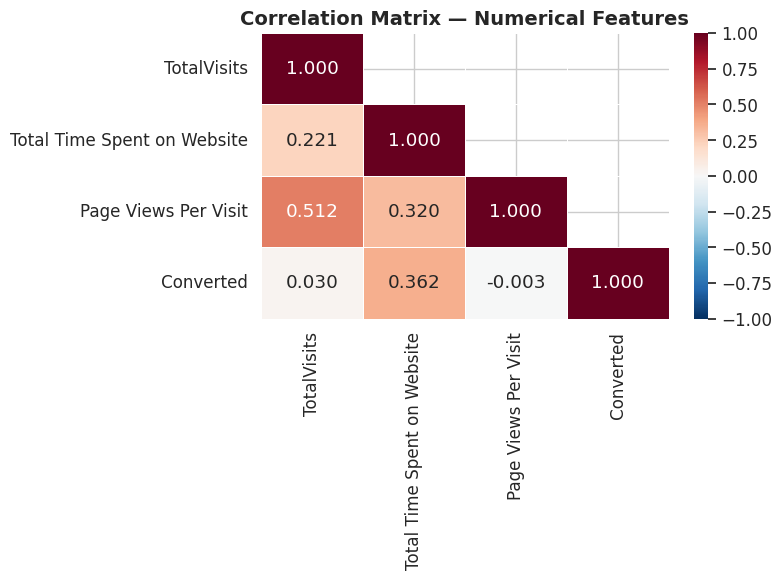

In [108]:
# Include target for correlation analysis
num_for_corr = numerical_cols_eda + ["Converted"]
corr_matrix = df[num_for_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0,
            mask=mask, ax=ax, fmt=".3f", linewidths=0.5,
            vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
- **Total Time Spent on Website** has the strongest positive correlation with
  `Converted` — leads who spend more time are more likely to convert.
- **TotalVisits** and **Page Views Per Visit** show positive correlation
  with each other (as expected — more visits → more page views).
- No feature pair is so highly correlated (>0.9) that we need to drop one
  due to multicollinearity.

---
# 7. Outlier Handling

## What are outliers?

Outliers are observations that fall far from the bulk of the data. They can
arise from:
- **Data entry errors** (e.g., someone typed 2510 instead of 25)
- **Legitimate extreme values** (e.g., a very engaged user visited 100 times)
- **Measurement issues** (e.g., bot traffic)

## Why handle outliers?

- They can disproportionately influence model training (especially linear models).
- They can inflate standard deviation and distort scaling.

## Our approach

We will use the **IQR (Interquartile Range)** method to detect outliers,
then apply **percentile capping** (winsorisation) rather than deletion,
because:
1. These extreme values may represent **real users** with unusual behaviour.
2. Deleting them reduces our dataset size.
3. Capping retains the "unusually high" signal without the extreme magnitude.

> **Important:** We will learn the capping thresholds **only from training
> data** to prevent data leakage. But first, let's inspect the outliers.

In [109]:
# IQR-based outlier detection
print("Outlier Analysis (IQR Method):\n")
print(f"{'Column':<35} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>8} {'Upper':>8} {'Outliers':>10} {'%':>6}")
print("-" * 100)

outlier_cols = []
for col in numerical_cols_eda:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((data < lower_bound) | (data > upper_bound)).sum()
    pct = n_outliers / len(data) * 100

    print(f"{col:<35} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {lower_bound:>8.1f} {upper_bound:>8.1f} {n_outliers:>10} {pct:>5.1f}%")

    if n_outliers > 0:
        outlier_cols.append(col)

Outlier Analysis (IQR Method):

Column                                    Q1       Q3      IQR    Lower    Upper   Outliers      %
----------------------------------------------------------------------------------------------------
TotalVisits                              1.0      5.0      4.0     -5.0     11.0        267   2.9%
Total Time Spent on Website             12.0    936.0    924.0  -1374.0   2322.0          0   0.0%
Page Views Per Visit                     1.0      3.0      2.0     -2.0      6.0        360   4.0%


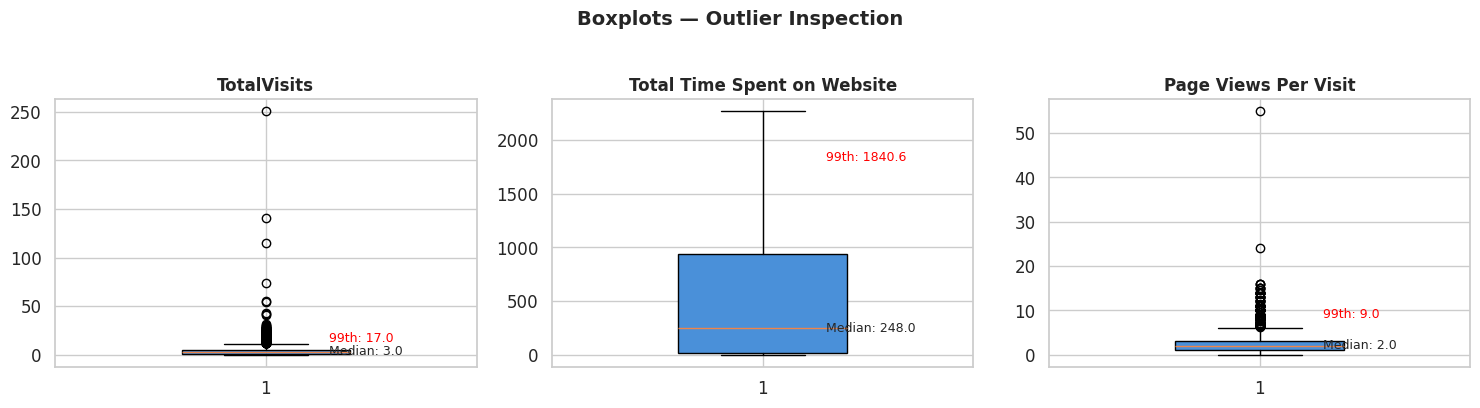

In [110]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(1, len(numerical_cols_eda), figsize=(5 * len(numerical_cols_eda), 4))
if len(numerical_cols_eda) == 1:
    axes = [axes]

for ax, col in zip(axes, numerical_cols_eda):
    data = df[col].dropna()
    bp = ax.boxplot(data, patch_artist=True, widths=0.4)
    bp["boxes"][0].set_facecolor("#4A90D9")
    ax.set_title(col, fontsize=12, fontweight="bold")

    # Annotate stats
    ax.text(1.15, data.median(), f"Median: {data.median():.1f}", va="center", fontsize=9)
    ax.text(1.15, data.quantile(0.99), f"99th: {data.quantile(0.99):.1f}", va="center", fontsize=9, color="red")

plt.suptitle("Boxplots — Outlier Inspection", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Outlier Treatment Decision

| Feature | Max Value | 99th Percentile | Decision |
|---------|-----------|-----------------|----------|
| TotalVisits | 251 | ~18 | Cap at 99th percentile — values above 18 are extreme but capping preserves the "high visit" signal |
| Page Views Per Visit | 55 | ~9 | Cap at 99th percentile — same reasoning |
| Total Time Spent on Website | 2272 | ~2272 | No outliers by IQR — max is within bounds |

We will apply the capping **after** the train/test split, using thresholds
learned only from training data (to prevent leakage).

In [111]:
# Store outlier column names for later capping
OUTLIER_COLS = [c for c in outlier_cols if c in ["TotalVisits", "Page Views Per Visit"]]
print(f"Columns to cap: {OUTLIER_COLS}")

Columns to cap: ['TotalVisits', 'Page Views Per Visit']


---
# 8. Feature Engineering

Feature engineering means **creating new features** from existing ones to
give the model more useful information. However, we should only create
features that:
1. Have a logical justification
2. Are not redundant with existing features
3. Can be computed at prediction time (no future-looking information)

## 8.1 Activity Channel Count

Several binary columns (`Search`, `Newspaper Article`, `X Education Forums`,
`Newspaper`, `Digital Advertisement`, `Through Recommendations`) indicate
whether the lead interacted through specific marketing channels.

Instead of keeping all these sparse binary columns, we can create a
single feature: **how many channels did the lead interact with?**

This captures the idea that leads who discover the company through
**multiple channels** may behave differently.

In [112]:
# Create Activity_Channel_Count
activity_cols = ["Search", "Newspaper Article", "X Education Forums",
                 "Newspaper", "Digital Advertisement", "Through Recommendations"]
existing_activity = [c for c in activity_cols if c in df.columns]

df["Activity_Channel_Count"] = df[existing_activity].apply(
    lambda row: (row == "Yes").sum(), axis=1
)

print("Activity_Channel_Count distribution:")
print(df["Activity_Channel_Count"].value_counts().sort_index())
print(f"\nConversion rate by channel count:")
print(df.groupby("Activity_Channel_Count")["Converted"].mean().round(3))

Activity_Channel_Count distribution:
Activity_Channel_Count
0    9240
Name: count, dtype: int64

Conversion rate by channel count:
Activity_Channel_Count
0    0.385
Name: Converted, dtype: float64


## 8.2 Should We Create Total_Engagement?

A common idea is to create `Total_Engagement = TotalVisits × Page Views Per Visit`.
But let's **verify** whether this adds information beyond the original features:

In [113]:
# Check if Total_Engagement adds value
df["Total_Engagement_test"] = df["TotalVisits"].fillna(0) * df["Page Views Per Visit"].fillna(0)

# Check correlation with existing features
corr_check = df[["TotalVisits", "Page Views Per Visit",
                  "Total_Engagement_test", "Converted"]].corr().round(3)
print("Correlation check:")
print(corr_check)
print()

# Compare correlation with target
print(f"TotalVisits → Converted:         {corr_check.loc['TotalVisits', 'Converted']:.3f}")
print(f"Page Views Per Visit → Converted: {corr_check.loc['Page Views Per Visit', 'Converted']:.3f}")
print(f"Total_Engagement → Converted:     {corr_check.loc['Total_Engagement_test', 'Converted']:.3f}")

Correlation check:
                       TotalVisits  Page Views Per Visit  \
TotalVisits                  1.000                 0.512   
Page Views Per Visit         0.512                 1.000   
Total_Engagement_test        0.587                 0.622   
Converted                    0.030                -0.003   

                       Total_Engagement_test  Converted  
TotalVisits                            0.587      0.030  
Page Views Per Visit                   0.622     -0.003  
Total_Engagement_test                  1.000     -0.002  
Converted                             -0.002      1.000  

TotalVisits → Converted:         0.030
Page Views Per Visit → Converted: -0.003
Total_Engagement → Converted:     -0.002


In [114]:
# Decision: Drop if it doesn't add meaningful signal
engagement_corr_target = abs(corr_check.loc["Total_Engagement_test", "Converted"])
visits_corr_target = abs(corr_check.loc["TotalVisits", "Converted"])

if engagement_corr_target <= visits_corr_target + 0.02:
    print("❌ Total_Engagement does NOT add meaningful signal beyond TotalVisits.")
    print("   Dropping it to avoid redundancy.")
    df = df.drop(columns=["Total_Engagement_test"])
else:
    print("✅ Total_Engagement adds some signal. Keeping it.")
    df = df.rename(columns={"Total_Engagement_test": "Total_Engagement"})

❌ Total_Engagement does NOT add meaningful signal beyond TotalVisits.
   Dropping it to avoid redundancy.


## 8.3 Drop Original Activity Binary Columns

Now that we have `Activity_Channel_Count`, we can drop the individual
binary activity columns to reduce dimensionality:

In [115]:
# Drop individual activity binary columns (replaced by Activity_Channel_Count)
cols_to_drop_activity = [c for c in existing_activity if c in df.columns]
df = df.drop(columns=cols_to_drop_activity)
print(f"✅ Dropped {len(cols_to_drop_activity)} individual activity columns.")
print(f"   Replaced by: Activity_Channel_Count")
print(f"\nDataset shape: {df.shape}")

✅ Dropped 0 individual activity columns.
   Replaced by: Activity_Channel_Count

Dataset shape: (9240, 16)


## 8.4 Feature Engineering Summary

| Feature | Type | Description | Justification |
|---------|------|-------------|---------------|
| Activity_Channel_Count | Engineered | Number of marketing channels the lead interacted with | Summarises 6 binary columns into a single engagement signal |

Remaining columns after all cleaning and engineering:

In [116]:
print(f"Final cleaned dataset: {df.shape[0]} rows × {df.shape[1]} columns\n")
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    missing = df[col].isnull().sum()
    missing_str = f"({missing} missing)" if missing > 0 else ""
    print(f"  {i:>2}. {col:<40} {str(dtype):<10} {missing_str}")

Final cleaned dataset: 9240 rows × 16 columns

   0. Lead Origin                              object     
   1. Lead Source                              object     (36 missing)
   2. Do Not Email                             object     
   3. Converted                                int64      
   4. TotalVisits                              float64    (137 missing)
   5. Total Time Spent on Website              int64      
   6. Page Views Per Visit                     float64    (137 missing)
   7. Last Activity                            object     (103 missing)
   8. Specialization                           object     (3380 missing)
   9. What is your current occupation          object     (2690 missing)
  10. What matters most to you in choosing a course object     (2709 missing)
  11. Tags                                     object     (3353 missing)
  12. City                                     object     (3669 missing)
  13. A free copy of Mastering The Interview   object     
 

---
# 9. Separate Features and Target

Before modelling, we separate the dataset into:
- **X** (features) — the input variables the model learns from
- **y** (target) — the variable we want to predict

This is a fundamental step in supervised learning.

In [117]:
TARGET = "Converted"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features (X): (9240, 15)
Target  (y): (9240,)

Target distribution:
Converted
0    5679
1    3561
Name: count, dtype: int64


---
# 10. Train / Test Split

## Why do we split the data?

We split into **training** and **testing** sets to evaluate how well the
model generalises to **unseen data**.

- **Training set (80 %)** — used to train the model and tune hyperparameters.
- **Test set (20 %)** — used **only once** at the very end for final evaluation.

## Why `stratify=y`?

Because the classes are imbalanced (~62 % / 38 %), a random split might
accidentally put too many of one class in one set. **Stratified** splitting
ensures both sets have the same class proportions as the full dataset.

## ⚠️ Data Leakage Warning

**Data leakage** occurs when information from the test set "leaks" into
the training process. Common causes:
1. Fitting a scaler on the full dataset, then splitting
2. Imputing missing values using statistics from the full dataset
3. Selecting features based on the full dataset

**Our solution:** We will fit all preprocessing steps (imputation, scaling,
encoding) **only on the training set** using scikit-learn Pipelines.
This is done automatically in Section 11.

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nTarget distribution in test set:")
print(y_test.value_counts(normalize=True).round(4))

Training set:  7,392 samples (80%)
Test set:      1,848 samples (20%)

Target distribution in training set:
Converted
0    0.6146
1    0.3854
Name: proportion, dtype: float64

Target distribution in test set:
Converted
0    0.6147
1    0.3853
Name: proportion, dtype: float64


### Apply Outlier Capping (Training-Data-Learned Thresholds)

We cap outliers **now** — after the split — using thresholds computed
only from training data. Then we apply the same thresholds to the test set.

In [119]:
# Cap outliers using training-data thresholds
for col in OUTLIER_COLS:
    train_99 = X_train[col].quantile(0.99)
    train_01 = X_train[col].quantile(0.01)

    print(f"{col}: capping to [{train_01:.1f}, {train_99:.1f}]")

    X_train[col] = X_train[col].clip(lower=train_01, upper=train_99)
    X_test[col] = X_test[col].clip(lower=train_01, upper=train_99)  # same thresholds!

print("\n✅ Outliers capped using training-data thresholds (no leakage).")

TotalVisits: capping to [0.0, 17.0]
Page Views Per Visit: capping to [0.0, 9.0]

✅ Outliers capped using training-data thresholds (no leakage).


---
# 11. Preprocessing Pipeline

## Why use Pipelines?

A `Pipeline` chains multiple preprocessing steps and a model together.
Benefits:
1. **Prevents data leakage** — each step is fit only on training data.
2. **Reproducibility** — the exact same transformations are applied at
   prediction time.
3. **Convenience** — a single `.fit()` and `.predict()` call handles everything.

## Our Preprocessing Strategy

| Feature Type | Steps | Reason |
|-------------|-------|--------|
| **Numerical** | `SimpleImputer(median)` → `StandardScaler` | Median is robust to outliers; scaling ensures equal feature influence |
| **Categorical** | `SimpleImputer(most_frequent)` → `OneHotEncoder` | Fill missing with mode; convert categories to binary columns |

We use `ColumnTransformer` to apply different pipelines to different
column types simultaneously.

In [120]:
# Identify numerical and categorical columns in X_train
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Numerical features ({len(numerical_features)}):")
for col in numerical_features:
    print(f"  • {col}")

print(f"\nCategorical features ({len(categorical_features)}):")
for col in categorical_features:
    print(f"  • {col}")

Numerical features (4):
  • TotalVisits
  • Total Time Spent on Website
  • Page Views Per Visit
  • Activity_Channel_Count

Categorical features (11):
  • Lead Origin
  • Lead Source
  • Do Not Email
  • Last Activity
  • Specialization
  • What is your current occupation
  • What matters most to you in choosing a course
  • Tags
  • City
  • A free copy of Mastering The Interview
  • Last Notable Activity


In [121]:
# Build the preprocessing pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("✅ Preprocessing pipeline created.")
print("\nPipeline structure:")
print(preprocessor)

✅ Preprocessing pipeline created.

Pipeline structure:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['TotalVisits', 'Total Time Spent on Website',
                                  'Page Views Per Visit',
                                  'Activity_Channel_Count']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Lead Origin

> **Key point:** The preprocessor will be combined with each model into a
> single `Pipeline`, so when we call `pipeline.fit(X_train, y_train)`, the
> preprocessing is automatically fitted **only on training data**.
> When we call `pipeline.predict(X_test)`, the **same** fitted transformations
> are applied to the test data. This is how we prevent data leakage.

---
# 12. Baseline Models

We start with two popular classification algorithms as baselines —
**before** any hyperparameter tuning — to establish a performance floor.

---

## 12.1 Logistic Regression

**How it works (high-level):**
- Learns a **linear decision boundary** between classes.
- Outputs a probability (0–1) using the sigmoid function.
- Fast, interpretable, and works well when the true boundary is roughly linear.

**Why use it:**
- Simple, fast baseline.
- Coefficients are directly interpretable (positive coefficient → increases
  conversion probability).

In [122]:
# Build Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight="balanced"  # handles class imbalance
    ))
])

# Train
print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
print("✅ Logistic Regression trained.")

Training Logistic Regression...
✅ Logistic Regression trained.


In [123]:
# Generate predictions
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression — Classification Report:")
print(classification_report(y_test, lr_pred, target_names=["Not Converted", "Converted"]))

Logistic Regression — Classification Report:
               precision    recall  f1-score   support

Not Converted       0.92      0.90      0.91      1136
    Converted       0.85      0.88      0.86       712

     accuracy                           0.89      1848
    macro avg       0.88      0.89      0.89      1848
 weighted avg       0.89      0.89      0.89      1848



## 12.2 Random Forest Classifier

**How it works (high-level):**
- Builds **many decision trees**, each trained on a random subset of data
  and features.
- Each tree "votes" on the prediction; the majority vote wins.
- Captures **non-linear** relationships and feature interactions.

**Why use it:**
- Robust, rarely overfits severely.
- Handles mixed feature types well.
- Provides feature importance scores.

In [124]:
# Build Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train
print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
print("✅ Random Forest trained.")

Training Random Forest...
✅ Random Forest trained.


In [125]:
# Generate predictions
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest — Classification Report:")
print(classification_report(y_test, rf_pred, target_names=["Not Converted", "Converted"]))

Random Forest — Classification Report:
               precision    recall  f1-score   support

Not Converted       0.90      0.92      0.91      1136
    Converted       0.86      0.84      0.85       712

     accuracy                           0.89      1848
    macro avg       0.88      0.88      0.88      1848
 weighted avg       0.89      0.89      0.89      1848



---
# 13. Baseline Model Evaluation

Now let's formally evaluate both baselines with our chosen metrics.

## Metric Definitions

| Metric | Formula | Meaning (for lead conversion) |
|--------|---------|-------------------------------|
| **Precision** | TP / (TP + FP) | "Of leads we predicted as converting, how many actually did?" |
| **Recall** | TP / (TP + FN) | "Of all leads that actually converted, how many did we catch?" |
| **F1-Score** | 2 × P × R / (P + R) | Harmonic mean — balances precision and recall |
| **ROC-AUC** | Area under ROC curve | How well the model distinguishes classes across all thresholds |

> **TP** = True Positive (correctly predicted conversion)\
> **FP** = False Positive (predicted conversion, but didn't convert)\
> **FN** = False Negative (missed a real conversion)

### Why F1 over Accuracy?
Accuracy treats all errors equally. But in lead conversion:
- **False negatives** mean we miss potential customers (lost revenue).
- **False positives** mean we waste sales effort on unlikely leads.
F1 balances these two types of errors.

In [126]:
# Calculate metrics for both baselines
def calc_metrics(y_true, y_pred, y_prob, name):
    return {
        "Model": name,
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "Accuracy": round((y_pred == y_true).mean(), 4),
    }

lr_metrics = calc_metrics(y_test, lr_pred, lr_prob, "Logistic Regression")
rf_metrics = calc_metrics(y_test, rf_pred, rf_prob, "Random Forest")

baseline_results = pd.DataFrame([lr_metrics, rf_metrics]).set_index("Model")
print("Baseline Model Comparison:")
baseline_results

Baseline Model Comparison:


,Precision,Recall,F1,ROC-AUC,Accuracy
Model,,,,,
Logistic Regression,0.8490,0.8764,0.8625,0.9491,0.8923
Random Forest,0.8644,0.8413,0.8527,0.9478,0.8880


## Confusion Matrices

A confusion matrix shows the four possible outcomes for each prediction.

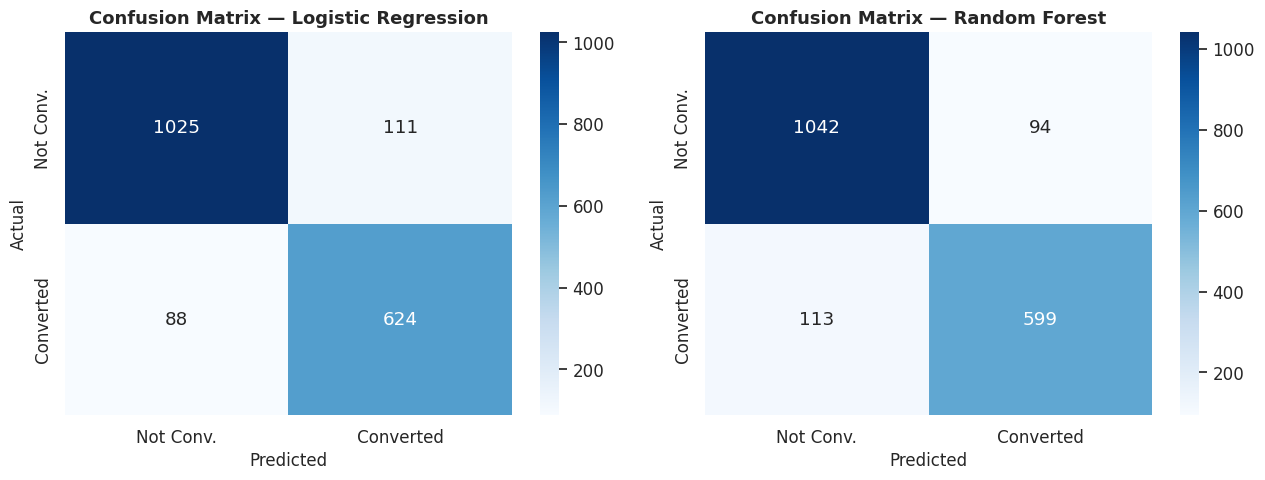

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, name in zip(axes, [lr_pred, rf_pred],
                             ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Conv.", "Converted"],
                yticklabels=["Not Conv.", "Converted"])
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## ROC Curves

The ROC curve plots **True Positive Rate** (recall) vs **False Positive Rate**
at every possible classification threshold.

- A perfect model hugs the top-left corner (AUC = 1.0).
- A random model follows the diagonal (AUC = 0.5).

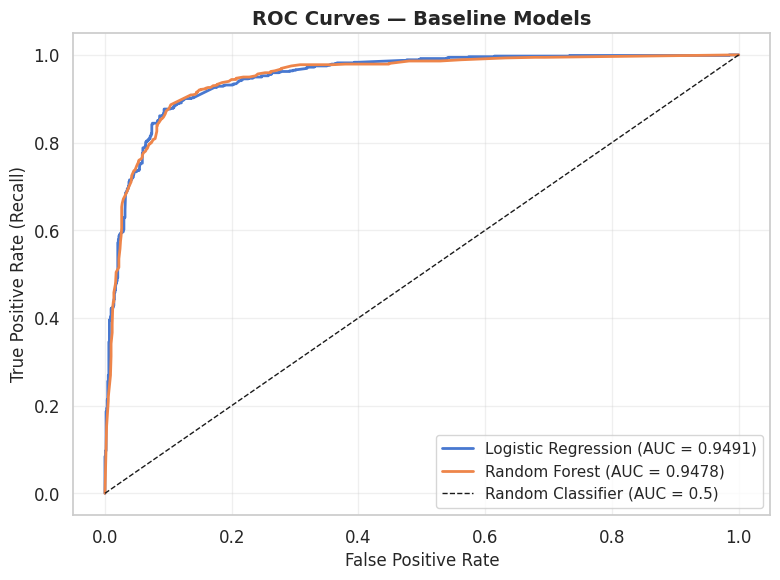

In [128]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob in [("Logistic Regression", lr_prob), ("Random Forest", rf_prob)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC = 0.5)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves — Baseline Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# 14. Hyperparameter Tuning

## What are hyperparameters?

Hyperparameters are settings that **we choose before training** — they are
not learned from data. Examples:
- How many trees in a random forest (`n_estimators`)
- How much regularisation for logistic regression (`C`)

## What is GridSearchCV?

`GridSearchCV` tries **every combination** of specified hyperparameter values
and evaluates each using **k-fold cross-validation** on the training set.

- `cv=5` means the training set is split into 5 folds. Each fold takes a
  turn as the validation set while the other 4 are used for training.
- `scoring='f1'` means we pick the combination that maximises F1-score.

> **Important:** GridSearchCV operates on the **complete pipeline**
> (preprocessor + model), so preprocessing is re-fitted within each fold.
> This prevents data leakage even during cross-validation.

---

## 14.1 Tune Logistic Regression

In [129]:
# Logistic Regression hyperparameter grid
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__class_weight": ["balanced", None],
}

print(f"Logistic Regression grid: {len(lr_param_grid['model__C'])} × "
      f"{len(lr_param_grid['model__solver'])} × "
      f"{len(lr_param_grid['model__class_weight'])} = "
      f"{np.prod([len(v) for v in lr_param_grid.values()])} combinations × 5 folds")

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

Logistic Regression grid: 4 × 2 × 2 = 16 combinations × 5 folds
Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TotalVisits',
                                                                          'Total '
                                                                          'Time '
                                                                          'Spent '
                                                                          'on '
                                                                          'Website',
                                                                          'Page '
                                                                          'Views '
                                                                          'Per '
                                                                          'Visit',
                                                                          'Activity_Channel_Count']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='...
                                                                          'choosing '
                                                                          'a '
                                                                          'course',
                                                                          'Tags',
                                                                          'City',
                                                                          'A '
                                                                          'free '
                                                                          'copy '
                                                                          'of '
                                                                          'Mastering '
                                                                          'The '
                                                                          'Interview',
                                                                          'Last '
                                                                          'Notable '
                                                                          'Activity'])])),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__class_weight': ['balanced', None],
                         'model__solver': ['lbfgs', 'liblinear']},
             scoring='f1', verbose=1)

In [130]:
print(f"Best Logistic Regression parameters:")
for param, value in lr_grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {lr_grid.best_score_:.4f}")

Best Logistic Regression parameters:
  model__C: 1
  model__class_weight: balanced
  model__solver: lbfgs

Best CV F1-Score: 0.8694


## 14.2 Tune Random Forest

In [131]:
# Random Forest hyperparameter grid
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": ["balanced", "balanced_subsample"],
}

total_combos = np.prod([len(v) for v in rf_param_grid.values()])
print(f"Random Forest grid: {int(total_combos)} combinations × 5 folds")

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

Random Forest grid: 48 combinations × 5 folds
Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TotalVisits',
                                                                          'Total '
                                                                          'Time '
                                                                          'Spent '
                                                                          'on '
                                                                          'Website',
                                                                          'Page '
                                                                          'Views '
                                                                          'Per '
                                                                          'Visit',
                                                                          'Activity_Channel_Count']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='...
                                                                          'Interview',
                                                                          'Last '
                                                                          'Notable '
                                                                          'Activity'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': ['balanced',
                                                 'balanced_subsample'],
                         'model__max_depth': [10, 20, None],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [132]:
print(f"Best Random Forest parameters:")
for param, value in rf_grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {rf_grid.best_score_:.4f}")

Best Random Forest parameters:
  model__class_weight: balanced_subsample
  model__max_depth: 20
  model__min_samples_leaf: 1
  model__min_samples_split: 5
  model__n_estimators: 100

Best CV F1-Score: 0.8779


---
# 15. Tuned Model Evaluation

Now we evaluate the tuned models on the **untouched test set** — the first
and only time we use it. This gives us an unbiased estimate of real-world
performance.

In [133]:
# Get predictions from tuned models
lr_tuned_pred = lr_grid.best_estimator_.predict(X_test)
lr_tuned_prob = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]

rf_tuned_pred = rf_grid.best_estimator_.predict(X_test)
rf_tuned_prob = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]

In [134]:
# Calculate metrics for tuned models
lr_tuned_metrics = calc_metrics(y_test, lr_tuned_pred, lr_tuned_prob, "Tuned Logistic Regression")
rf_tuned_metrics = calc_metrics(y_test, rf_tuned_pred, rf_tuned_prob, "Tuned Random Forest")

# Final comparison table (all 4 models)
all_results = pd.DataFrame([lr_metrics, rf_metrics, lr_tuned_metrics, rf_tuned_metrics])
all_results = all_results.set_index("Model")

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
all_results

FINAL MODEL COMPARISON


,Precision,Recall,F1,ROC-AUC,Accuracy
Model,,,,,
Logistic Regression,0.8490,0.8764,0.8625,0.9491,0.8923
Random Forest,0.8644,0.8413,0.8527,0.9478,0.8880
Tuned Logistic Regression,0.8490,0.8764,0.8625,0.9491,0.8923
Tuned Random Forest,0.8635,0.8708,0.8671,0.9526,0.8972


## Confusion Matrices — Tuned Models

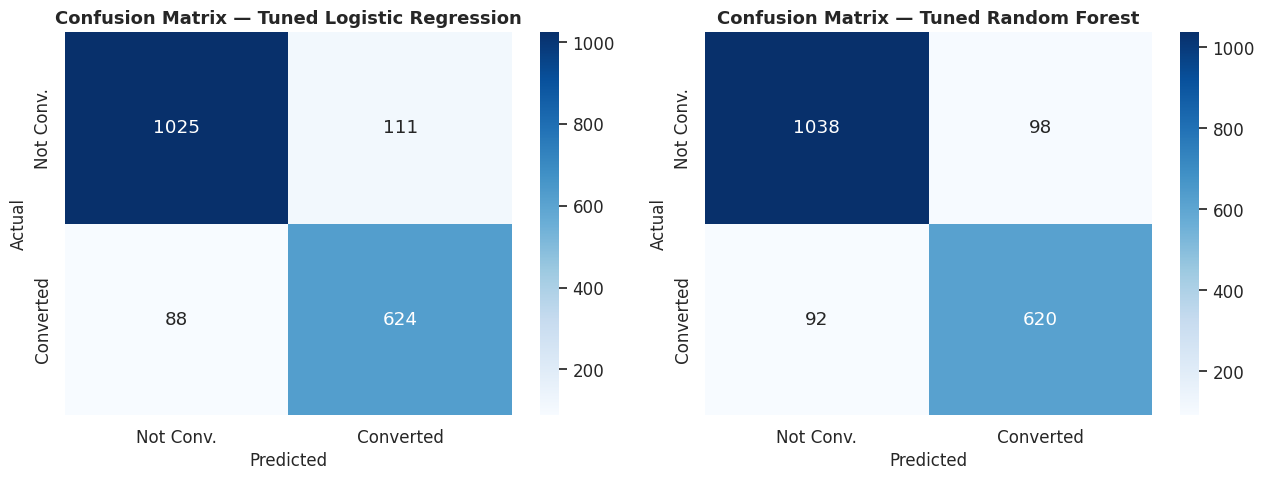

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, name in zip(axes, [lr_tuned_pred, rf_tuned_pred],
                             ["Tuned Logistic Regression", "Tuned Random Forest"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Conv.", "Converted"],
                yticklabels=["Not Conv.", "Converted"])
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## ROC Curves — All Models

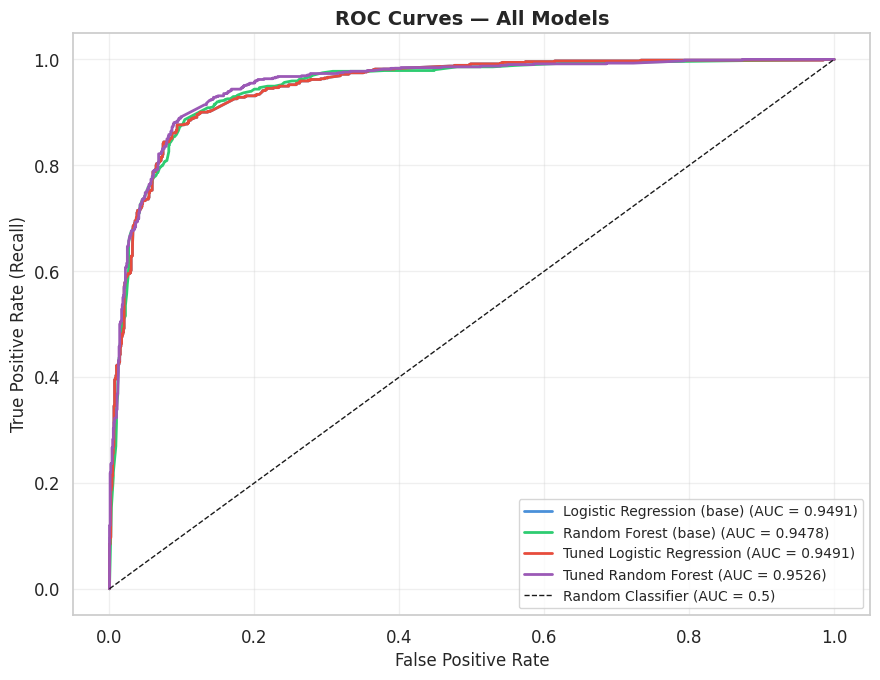

In [136]:
fig, ax = plt.subplots(figsize=(9, 7))

roc_data = [
    ("Logistic Regression (base)", lr_prob),
    ("Random Forest (base)", rf_prob),
    ("Tuned Logistic Regression", lr_tuned_prob),
    ("Tuned Random Forest", rf_tuned_prob),
]

colors = ["#4A90D9", "#2ECC71", "#E74C3C", "#9B59B6"]
for (name, y_prob), color in zip(roc_data, colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f"{name} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC = 0.5)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model Comparison Bar Chart

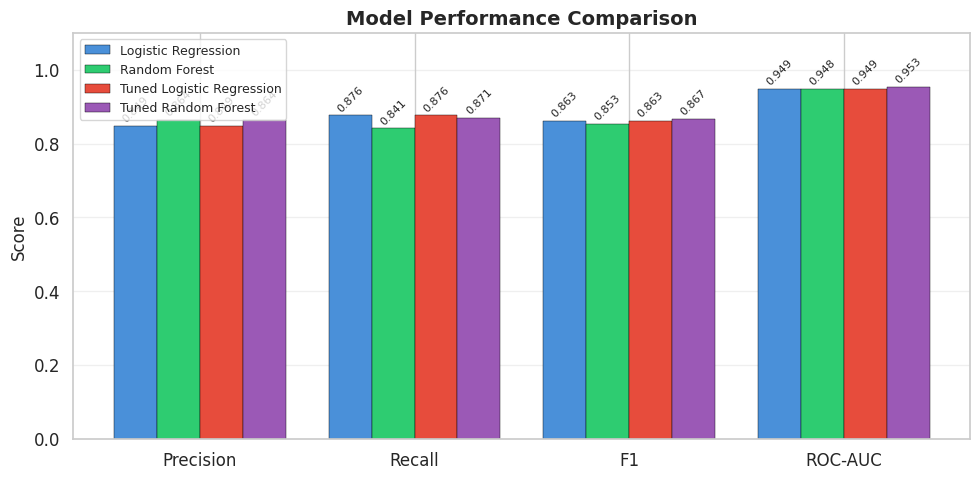

In [137]:
fig, ax = plt.subplots(figsize=(10, 5))

metrics_to_plot = ["Precision", "Recall", "F1", "ROC-AUC"]
x = np.arange(len(metrics_to_plot))
width = 0.2

models = all_results.index.tolist()
colors = ["#4A90D9", "#2ECC71", "#E74C3C", "#9B59B6"]

for i, (model, color) in enumerate(zip(models, colors)):
    values = [all_results.loc[model, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=model, color=color, edgecolor="black", linewidth=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, rotation=45)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
# 16. Feature Importance / Model Interpretability

Understanding **which features** the model considers important is crucial for:
1. **Trust** — Are the model's decisions reasonable?
2. **Business insights** — What drives conversion?
3. **Debugging** — Is the model relying on spurious patterns?

## 16.1 Random Forest Feature Importance

Random Forest computes importance based on how much each feature reduces
impurity (Gini) across all trees. Higher = more important.

In [138]:
# Extract feature names after preprocessing
best_rf = rf_grid.best_estimator_

# Get feature names from the preprocessor
ohe = best_rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + cat_feature_names

# Get importance values
importances = best_rf.named_steps["model"].feature_importances_

# Create DataFrame and sort
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 Most Important Features (Random Forest):\n")
print(importance_df.head(15).to_string(index=False))

Top 15 Most Important Features (Random Forest):

                                             Feature  Importance
                         Total Time Spent on Website    0.176504
            Tags_Will revert after reading the email    0.086753
                                        Tags_Ringing    0.067435
                      Last Notable Activity_SMS Sent    0.066273
                              Last Activity_SMS Sent    0.052177
                           Lead Origin_Lead Add Form    0.043626
                             Tags_Closed by Horizzon    0.038413
What is your current occupation_Working Professional    0.037020
                      Last Notable Activity_Modified    0.030648
                                         TotalVisits    0.027841
                                   Tags_Lost to EINS    0.026901
          What is your current occupation_Unemployed    0.025969
                                Page Views Per Visit    0.024607
                               Lead Sourc

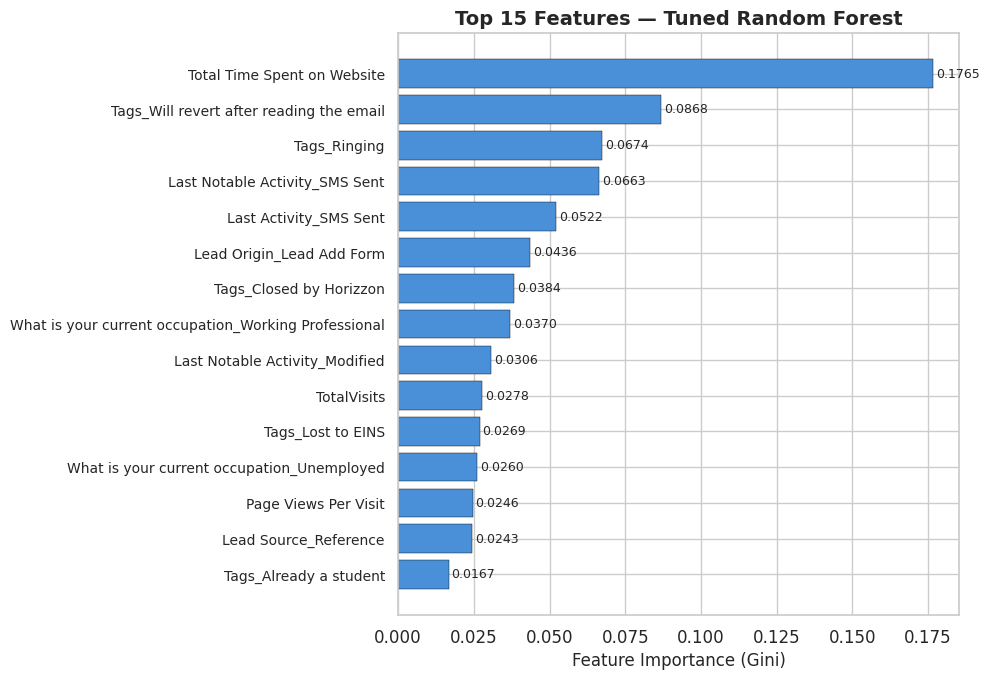

In [139]:
# Plot top 15 features
top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(top_n), top_features["Importance"].values[::-1],
               color="#4A90D9", edgecolor="black", linewidth=0.3)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["Feature"].values[::-1], fontsize=10)
ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_title("Top 15 Features — Tuned Random Forest", fontsize=14, fontweight="bold")

for bar, val in zip(bars, top_features["Importance"].values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 16.2 Logistic Regression Coefficients

In Logistic Regression, each feature has a **coefficient**:
- **Positive coefficient** → increases the log-odds of conversion.
- **Negative coefficient** → decreases the log-odds of conversion.
- **Larger magnitude** → stronger influence.

> ⚠️ **Important caveat:** These coefficients show **associations**, not
> causation. A feature with a large positive coefficient is associated with
> higher conversion probability, but it does not prove that changing that
> feature would cause more conversions.

In [140]:
# Extract LR coefficients
best_lr = lr_grid.best_estimator_
lr_coefs = best_lr.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": lr_coefs
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)

# Show top 10 positive and top 10 negative
print("Top 10 POSITIVE coefficients (favour conversion):\n")
print(coef_df.head(10).to_string(index=False))
print()
print("Top 10 NEGATIVE coefficients (disfavour conversion):\n")
print(coef_df.tail(10).to_string(index=False))

Top 10 POSITIVE coefficients (favour conversion):

                                             Feature  Coefficient
                                   Tags_Lost to EINS     5.599114
                             Tags_Closed by Horizzon     5.545643
            Tags_Will revert after reading the email     2.067598
                           Lead Origin_Lead Add Form     1.971042
                                           Tags_Busy     1.455329
                      Last Notable Activity_SMS Sent     1.357454
                        Lead Source_Welingak Website     1.329516
      Last Notable Activity_Had a Phone Conversation     1.307498
What is your current occupation_Working Professional     1.223055
                 Last Notable Activity_Email Bounced     1.160800

Top 10 NEGATIVE coefficients (disfavour conversion):

                                   Feature  Coefficient
          Tags_Interested in other courses    -1.296760
        Tags_Diploma holder (Not Eligible)    -1.385782


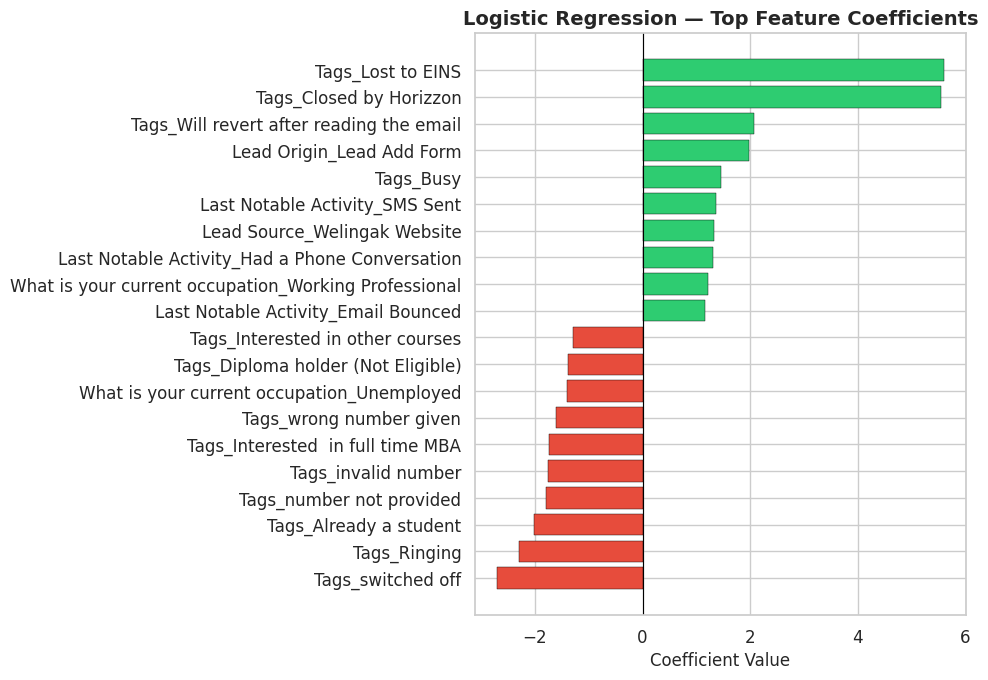

In [141]:
# Plot top/bottom coefficients
n_show = 10
top_pos = coef_df.head(n_show)
top_neg = coef_df.tail(n_show)
plot_df = pd.concat([top_pos, top_neg]).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E74C3C" if c < 0 else "#2ECC71" for c in plot_df["Coefficient"]]
ax.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors, edgecolor="black", linewidth=0.3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient Value", fontsize=12)
ax.set_title("Logistic Regression — Top Feature Coefficients", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
# 17. Business Interpretation

## Key Findings

Based on the model analysis:

### Important Features for Lead Conversion
The model identifies several factors associated with higher conversion:

1. **Total Time Spent on Website** — Leads who spend more time exploring
   the website are significantly more likely to convert. This suggests that
   website engagement is a strong indicator of purchase intent.

2. **Lead Source / Origin** — The channel through which a lead arrives
   matters. Some sources (e.g., referrals, specific landing pages) tend
   to produce higher-quality leads.

3. **Last Activity** — The recency and type of interaction (e.g., SMS sent,
   email opened) are associated with conversion likelihood.

4. **Occupation** — Working professionals and students show different
   conversion patterns, which may reflect different motivations and
   purchasing ability.

## How the Sales Team Could Use This Model

1. **Lead Scoring:** Assign each new lead a predicted conversion probability.
   Leads scoring above a threshold (e.g., 0.5) are flagged as "Hot Leads".

2. **Prioritisation:** Sales representatives focus their limited time on
   Hot Leads first, improving conversion rates without increasing headcount.

3. **Tailored Outreach:** Leads from different sources or with different
   engagement patterns may respond to different communication strategies.

## Consequences of Prediction Errors

| Error Type | Business Impact |
|------------|----------------|
| **False Positive** (predicted convert, didn't) | Sales team wastes effort on unlikely leads. Cost = time + opportunity cost. |
| **False Negative** (predicted no convert, did) | Potential customer receives less attention and may be lost. Cost = lost revenue. |

The balance between precision and recall depends on the company's situation:
- If the sales team is small → prioritise **precision** (fewer, better leads).
- If revenue growth is critical → prioritise **recall** (catch every possible conversion).

## ⚠️ Correlation ≠ Causation

The model identifies **patterns in historical data**. It does **not** prove
that changing a feature will cause more conversions. For example:
- "Leads who spend more time on the website convert more" does NOT mean
  "forcing leads to stay on the website will make them convert."
- The features might be **proxies** for deeper factors (e.g., genuine
  interest, financial readiness) that we cannot directly measure.

---
# 18. Limitations

No ML model is perfect. Understanding limitations is as important as
understanding results.

### 1. Data Quality
- **High missing rates:** Several columns had 30–50 % missing values and
  were dropped. If this data were available, the model might perform better.
- **"Select" placeholders:** An unknown number of leads simply skipped
  optional fields, creating systematic bias in certain features.

### 2. Class Imbalance
- The ~62/38 split is moderate but still means the model may be biased
  toward the majority class. We mitigated this with `class_weight='balanced'`
  but it remains a consideration.

### 3. Temporal Effects
- The dataset is a snapshot. Lead conversion patterns may change over time
  (seasonal trends, marketing campaign changes). A model trained on historical
  data may not generalise to future leads without periodic retraining.

### 4. Feature Availability at Prediction Time
- Some features (e.g., `Tags`, `Last Activity`) may only be fully known
  **after** the lead has been processed by the CRM. If the model is deployed
  for real-time scoring of new leads, only features available at lead creation
  time should be used.

### 5. Data Leakage Risk in Real CRM Systems
- Features like `Tags` (e.g., "Already a student") may encode **future
  information** — the CRM team might tag a lead *after* they convert. Such
  features should be excluded in a production deployment.

### 6. Generalisation
- The model was trained on X Education's specific data. It would not
  directly transfer to a different company, industry, or geography.

### 7. Causation
- All findings are **correlational**. The model cannot identify causal
  mechanisms. Experimental interventions (A/B tests) would be needed to
  establish causality.

---
# 19. Conclusion

## What We Built

An **end-to-end machine learning pipeline** for predicting lead conversion:

1. **Data Loading & Inspection** — Understood the dataset structure (9,240 leads × 37 columns).
2. **Data Quality Assessment** — Handled missing values, "Select" placeholders,
   constant columns, and high-missingness columns.
3. **Exploratory Data Analysis** — Identified key patterns: website engagement
   time is the strongest numerical predictor; lead source and activity type
   matter.
4. **Outlier Handling** — Capped extreme values in TotalVisits and Page Views
   Per Visit using training-data thresholds (no leakage).
5. **Feature Engineering** — Created Activity_Channel_Count; verified and
   discarded Total_Engagement (redundant).
6. **Preprocessing Pipeline** — Used ColumnTransformer with separate
   numerical and categorical pipelines to prevent data leakage.
7. **Baseline Models** — Logistic Regression and Random Forest with default
   hyperparameters.
8. **Hyperparameter Tuning** — GridSearchCV (5-fold CV, F1 scoring) to
   find optimal parameters.
9. **Final Evaluation** — Compared all models on the untouched test set
   using Precision, Recall, F1, ROC-AUC, and Confusion Matrices.
10. **Interpretability** — Extracted feature importances and coefficients
    to understand what drives predictions.
11. **Business Interpretation** — Translated model outputs into actionable
    business recommendations.

## Future Improvements

- Collect more complete data (reduce missing values).
- Experiment with additional models (Gradient Boosting, XGBoost).
- Implement SMOTE or other resampling techniques for class imbalance.
- Build a real-time scoring API for CRM integration.
- Conduct A/B tests to validate causal hypotheses from model insights.
- Add time-based validation (train on older data, test on newer data).

---
# 20. A02 Assignment Compliance Checklist

| # | Requirement | Status | Section |
|---|-------------|--------|---------|
| 1 | Python + Pandas + NumPy + Scikit-learn + Matplotlib + Seaborn | ✅ | §2 |
| 2 | Load and inspect dataset | ✅ | §3, §4 |
| 3 | Data quality assessment (missing values, duplicates) | ✅ | §5 |
| 4 | Handle missing values | ✅ | §5, §11 (imputation in pipeline) |
| 5 | Handle duplicate records | ✅ | §5.3 |
| 6 | Handle outliers | ✅ | §7 (IQR detection + percentile capping) |
| 7 | Exploratory Data Analysis with visualisations | ✅ | §6 |
| 8 | Feature engineering | ✅ | §8 |
| 9 | Categorical encoding (OneHotEncoder) | ✅ | §11 |
| 10 | Feature scaling (StandardScaler) | ✅ | §11 |
| 11 | Train/test split (80/20, stratified) | ✅ | §10 |
| 12 | Data leakage prevention | ✅ | §10, §11 (Pipeline) |
| 13 | Baseline classification models (≥2) | ✅ | §12 (LR + RF) |
| 14 | Model evaluation (Precision, Recall, F1, ROC-AUC) | ✅ | §13, §15 |
| 15 | Confusion matrix visualisation | ✅ | §13, §15 |
| 16 | ROC curve visualisation | ✅ | §13, §15 |
| 17 | Hyperparameter tuning (GridSearchCV, cv=5) | ✅ | §14 |
| 18 | Model comparison table | ✅ | §15 |
| 19 | Feature importance visualisation | ✅ | §16 |
| 20 | Business interpretation | ✅ | §17 |
| 21 | Limitations discussion | ✅ | §18 |
| 22 | Clean project structure | ✅ | README.md |
| 23 | PEP8 compliant code | ✅ | Throughout |
| 24 | Google Colab compatible | ✅ | §3 (upload cell) |
| 25 | Reproducible (random_state=42) | ✅ | §2 |